In [1]:
from tqdm import tqdm

import torch
import torch.nn as nn

from eeg.big_hand.position_llm.vqvae import VQVAE
from eeg.big_hand.position_llm import PositionLLM
from eeg.big_hand.position_llm import AppendageDataset

import matplotlib.pyplot as plt

In [2]:
device = "cuda"

vqvae = VQVAE(input_dim=12,
              codebook_size=512,
              embedding_dim=1024)

vqvae_state_dict = torch.load("/var/log/thavamount/eeg_ckpts/final_ckpts/vqvae.pth", map_location="cuda")
vqvae.load_state_dict(vqvae_state_dict["model"])

vqvae = vqvae.to(device).eval()

In [5]:
model = PositionLLM(
    vocab_size=512,
    num_layers=4,
    num_heads=4,
    embedding_dim=256,
    ffn_hidden_dim=256,
    qk_length=256,
    value_length=256,
    max_length=2048,
    dropout=0.1,
    duration_prediction=True
)

# model.load_state_dict(torch.load("/var/log/thavamount/eeg_ckpts/eeg_vqvae/e2e_posllm_vqvae_latest.pth", map_location="cpu")["model"])
model.load_state_dict(torch.load("/var/log/thavamount/eeg_ckpts/hand_lm/log_pos_llm_duration_256_tril_fix.pth", map_location="cpu")["model"])
model = model.to(device).eval()

In [4]:
dataset = AppendageDataset(region_tokenizer_path="../models/appendages", duration_prediction=True)

Pre-computing VQ-VAE tokens...


100%|██████████| 309/309 [00:04<00:00, 74.77it/s]


# Data analysis using VQ-VAE

## Token marginal distribution

In [7]:
# P(z)

vocab_size = 512

In [20]:
all_toks = []

for data in tqdm(dataset):
    kmeans_data, data = data
    data = torch.tensor(data).to(device).float()
    with torch.no_grad():
        toks = vqvae(data.unsqueeze(0), return_toks=True)
        all_toks.append(toks.squeeze(0).cpu())

100%|██████████| 700/700 [00:05<00:00, 136.47it/s]


In [21]:
all_toks = torch.cat(all_toks, dim=0)

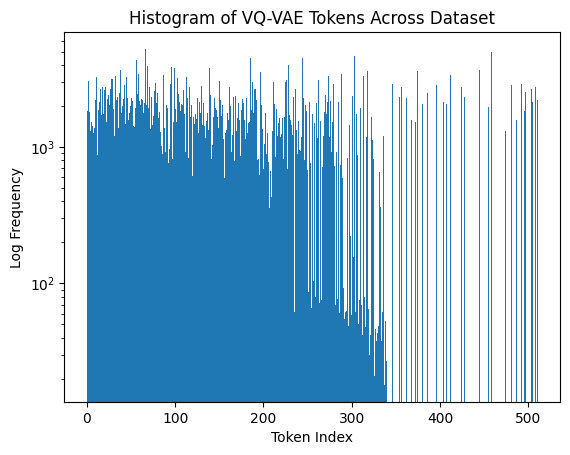

In [24]:
plt.hist(all_toks.numpy().flatten(), bins=vocab_size)
plt.yscale("log")
plt.title("Histogram of VQ-VAE Tokens Across Dataset")
plt.xlabel("Token Index")
plt.ylabel("Log Frequency")
plt.show()

## Token self-transition matrix

In [25]:
# p(z_{t+1} | z_t)

import numpy as np

transition_matrix = np.zeros((vocab_size, vocab_size), dtype=np.int64)

for data in tqdm(dataset):
    kmeans_data, data = data
    data = torch.tensor(data).to(device).float()
    with torch.no_grad():
        toks = vqvae(data.unsqueeze(0), return_toks=True)
        toks = toks.squeeze(0).cpu().numpy()
        
        for i in range(len(toks) - 1):
            current_tok = toks[i]
            next_tok = toks[i + 1]
            transition_matrix[current_tok, next_tok] += 1

transition_prob = transition_matrix.astype(np.float64)
row_sums = transition_prob.sum(axis=1, keepdims=True)

row_sums[row_sums == 0] = 1
transition_prob = transition_prob / row_sums

print(f"Total transitions counted: {transition_matrix.sum()}")
print(f"Non-zero transitions: {(transition_matrix > 0).sum()} out of {vocab_size * vocab_size}")


100%|██████████| 700/700 [00:05<00:00, 128.12it/s]

Total transitions counted: 629300
Non-zero transitions: 55808 out of 262144


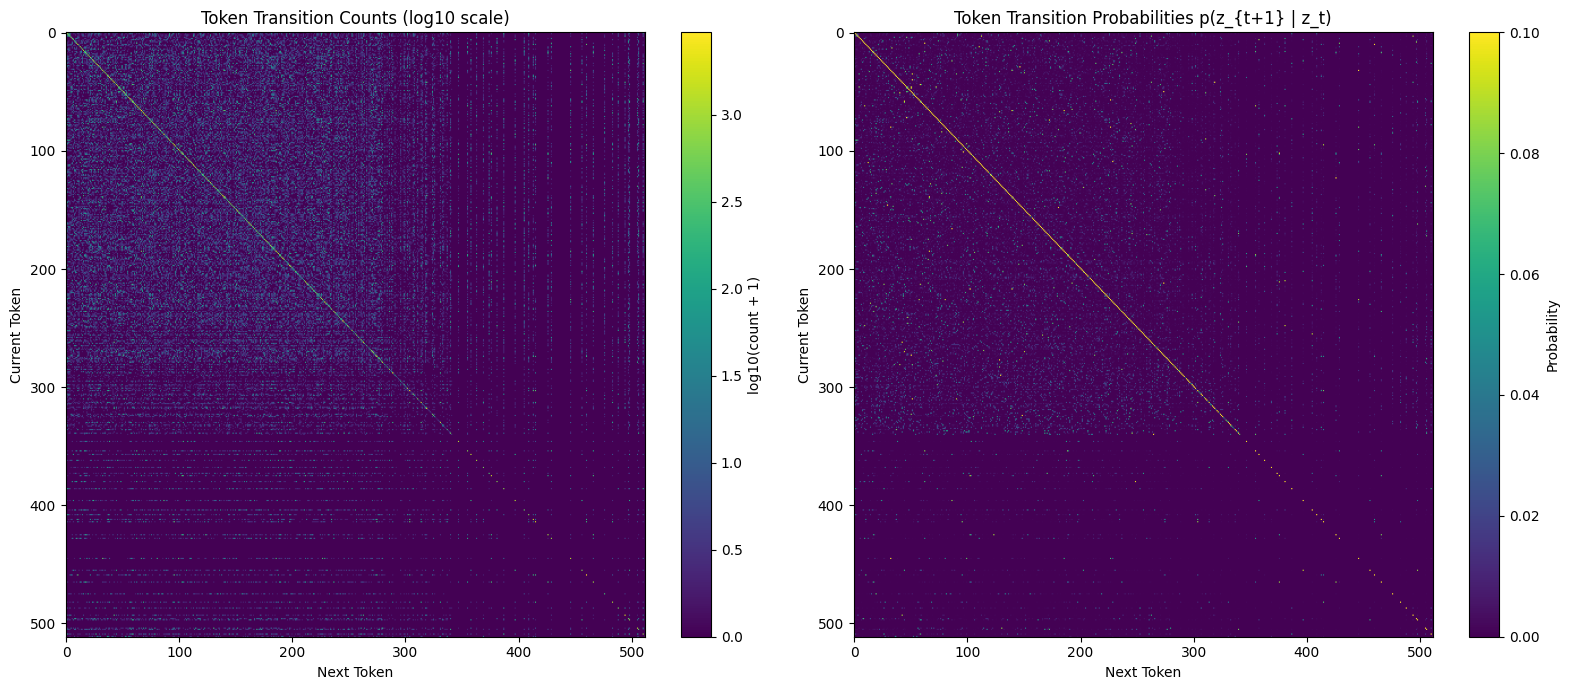


Transition matrix statistics:
Mean transition probability: 0.006648
Max transition probability: 0.726831
Median non-zero transition probability: 0.001366


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

im1 = axes[0].imshow(np.log10(transition_matrix + 1), cmap='viridis', aspect='auto')
axes[0].set_title("Token Transition Counts (log10 scale)")
axes[0].set_xlabel("Next Token")
axes[0].set_ylabel("Current Token")
plt.colorbar(im1, ax=axes[0], label='log10(count + 1)')

im2 = axes[1].imshow(transition_prob, cmap='viridis', aspect='auto', vmin=0, vmax=0.1)
axes[1].set_title("Token Transition Probabilities p(z_{t+1} | z_t)")
axes[1].set_xlabel("Next Token")
axes[1].set_ylabel("Current Token")
plt.colorbar(im2, ax=axes[1], label='Probability')

plt.tight_layout()
plt.show()

print(f"\nTransition matrix statistics:")
print(f"Mean transition probability: {transition_prob[transition_prob > 0].mean():.6f}")
print(f"Max transition probability: {transition_prob.max():.6f}")
print(f"Median non-zero transition probability: {np.median(transition_prob[transition_prob > 0]):.6f}")


## Run-length statistics

In [27]:
from collections import defaultdict

token_run_lengths = defaultdict(list)

for data in tqdm(dataset):
    kmeans_data, data = data
    data = torch.tensor(data).to(device).float()
    with torch.no_grad():
        toks = vqvae(data.unsqueeze(0), return_toks=True)
        toks = toks.squeeze(0).cpu().numpy()
        
        if len(toks) > 0:
            current_token = toks[0]
            run_length = 1
            
            for i in range(1, len(toks)):
                if toks[i] == current_token:
                    run_length += 1
                else:
                    token_run_lengths[current_token].append(run_length)
                    current_token = toks[i]
                    run_length = 1
            
            token_run_lengths[current_token].append(run_length)

token_stats = {}
for token_id in range(vocab_size):
    if token_id in token_run_lengths and len(token_run_lengths[token_id]) > 0:
        run_lengths = np.array(token_run_lengths[token_id])
        token_stats[token_id] = {
            'mean': np.mean(run_lengths),
            'median': np.median(run_lengths),
            'p95': np.percentile(run_lengths, 95),
            'count': len(run_lengths),
            'total_frames': np.sum(run_lengths)
        }

print(f"\nRun-length statistics computed for {len(token_stats)} tokens (out of {vocab_size})")
print(f"Total number of runs: {sum(s['count'] for s in token_stats.values())}")
print(f"\nTokens with longest mean run-length:")
sorted_by_mean = sorted(token_stats.items(), key=lambda x: x[1]['mean'], reverse=True)
for token_id, stats in sorted_by_mean[:10]:
    print(f"  Token {token_id:3d}: mean={stats['mean']:.2f}, median={stats['median']:.1f}, p95={stats['p95']:.1f}, count={stats['count']}")


100%|██████████| 700/700 [00:05<00:00, 132.24it/s]


Run-length statistics computed for 371 tokens (out of 512)
Total number of runs: 426111

Tokens with longest mean run-length:
  Token 112: mean=3.66, median=1.0, p95=14.0, count=900
  Token 511: mean=3.12, median=1.0, p95=12.0, count=706
  Token 288: mean=2.58, median=1.0, p95=9.0, count=1320
  Token 191: mean=2.57, median=1.0, p95=8.0, count=1036
  Token 493: mean=2.56, median=1.0, p95=7.0, count=1132
  Token 459: mean=2.48, median=1.0, p95=8.0, count=2002
  Token 237: mean=2.36, median=1.0, p95=7.0, count=561
  Token 244: mean=2.34, median=1.0, p95=8.0, count=1909
  Token 146: mean=2.32, median=1.0, p95=7.5, count=271
  Token 318: mean=2.31, median=1.0, p95=7.0, count=1566


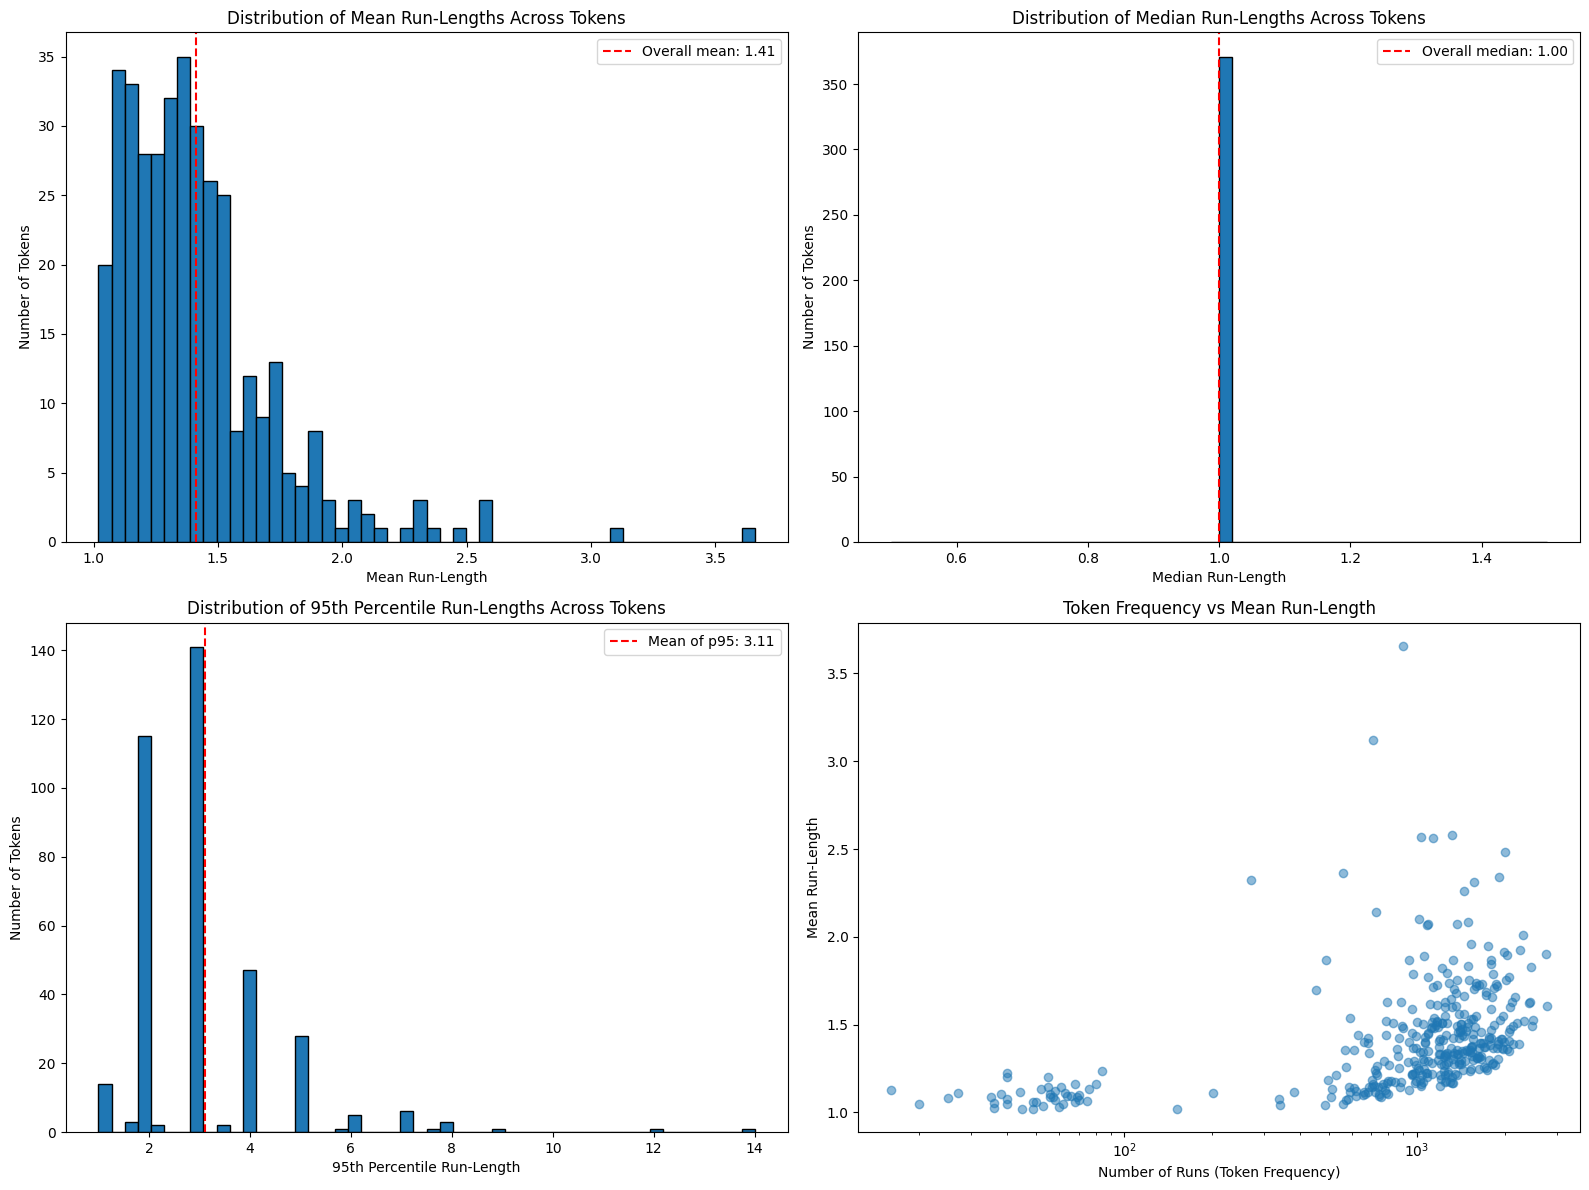


Overall run-length statistics across all tokens:
  Mean of means: 1.41
  Median of medians: 1.00
  Mean of 95th percentiles: 3.11


In [28]:
# Visualize run-length statistics

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of mean run-lengths across all tokens
mean_run_lengths = [stats['mean'] for stats in token_stats.values()]
axes[0, 0].hist(mean_run_lengths, bins=50, edgecolor='black')
axes[0, 0].set_xlabel('Mean Run-Length')
axes[0, 0].set_ylabel('Number of Tokens')
axes[0, 0].set_title('Distribution of Mean Run-Lengths Across Tokens')
axes[0, 0].axvline(np.mean(mean_run_lengths), color='red', linestyle='--', 
                    label=f'Overall mean: {np.mean(mean_run_lengths):.2f}')
axes[0, 0].legend()

# 2. Distribution of median run-lengths across all tokens
median_run_lengths = [stats['median'] for stats in token_stats.values()]
axes[0, 1].hist(median_run_lengths, bins=50, edgecolor='black')
axes[0, 1].set_xlabel('Median Run-Length')
axes[0, 1].set_ylabel('Number of Tokens')
axes[0, 1].set_title('Distribution of Median Run-Lengths Across Tokens')
axes[0, 1].axvline(np.median(median_run_lengths), color='red', linestyle='--',
                    label=f'Overall median: {np.median(median_run_lengths):.2f}')
axes[0, 1].legend()

# 3. Distribution of 95th percentile run-lengths across all tokens
p95_run_lengths = [stats['p95'] for stats in token_stats.values()]
axes[1, 0].hist(p95_run_lengths, bins=50, edgecolor='black')
axes[1, 0].set_xlabel('95th Percentile Run-Length')
axes[1, 0].set_ylabel('Number of Tokens')
axes[1, 0].set_title('Distribution of 95th Percentile Run-Lengths Across Tokens')
axes[1, 0].axvline(np.mean(p95_run_lengths), color='red', linestyle='--',
                    label=f'Mean of p95: {np.mean(p95_run_lengths):.2f}')
axes[1, 0].legend()

# 4. Token usage (frequency) vs mean run-length
token_counts = [stats['count'] for stats in token_stats.values()]
axes[1, 1].scatter(token_counts, mean_run_lengths, alpha=0.5)
axes[1, 1].set_xlabel('Number of Runs (Token Frequency)')
axes[1, 1].set_ylabel('Mean Run-Length')
axes[1, 1].set_title('Token Frequency vs Mean Run-Length')
axes[1, 1].set_xscale('log')

plt.tight_layout()
plt.show()

print(f"\nOverall run-length statistics across all tokens:")
print(f"  Mean of means: {np.mean(mean_run_lengths):.2f}")
print(f"  Median of medians: {np.median(median_run_lengths):.2f}")
print(f"  Mean of 95th percentiles: {np.mean(p95_run_lengths):.2f}")


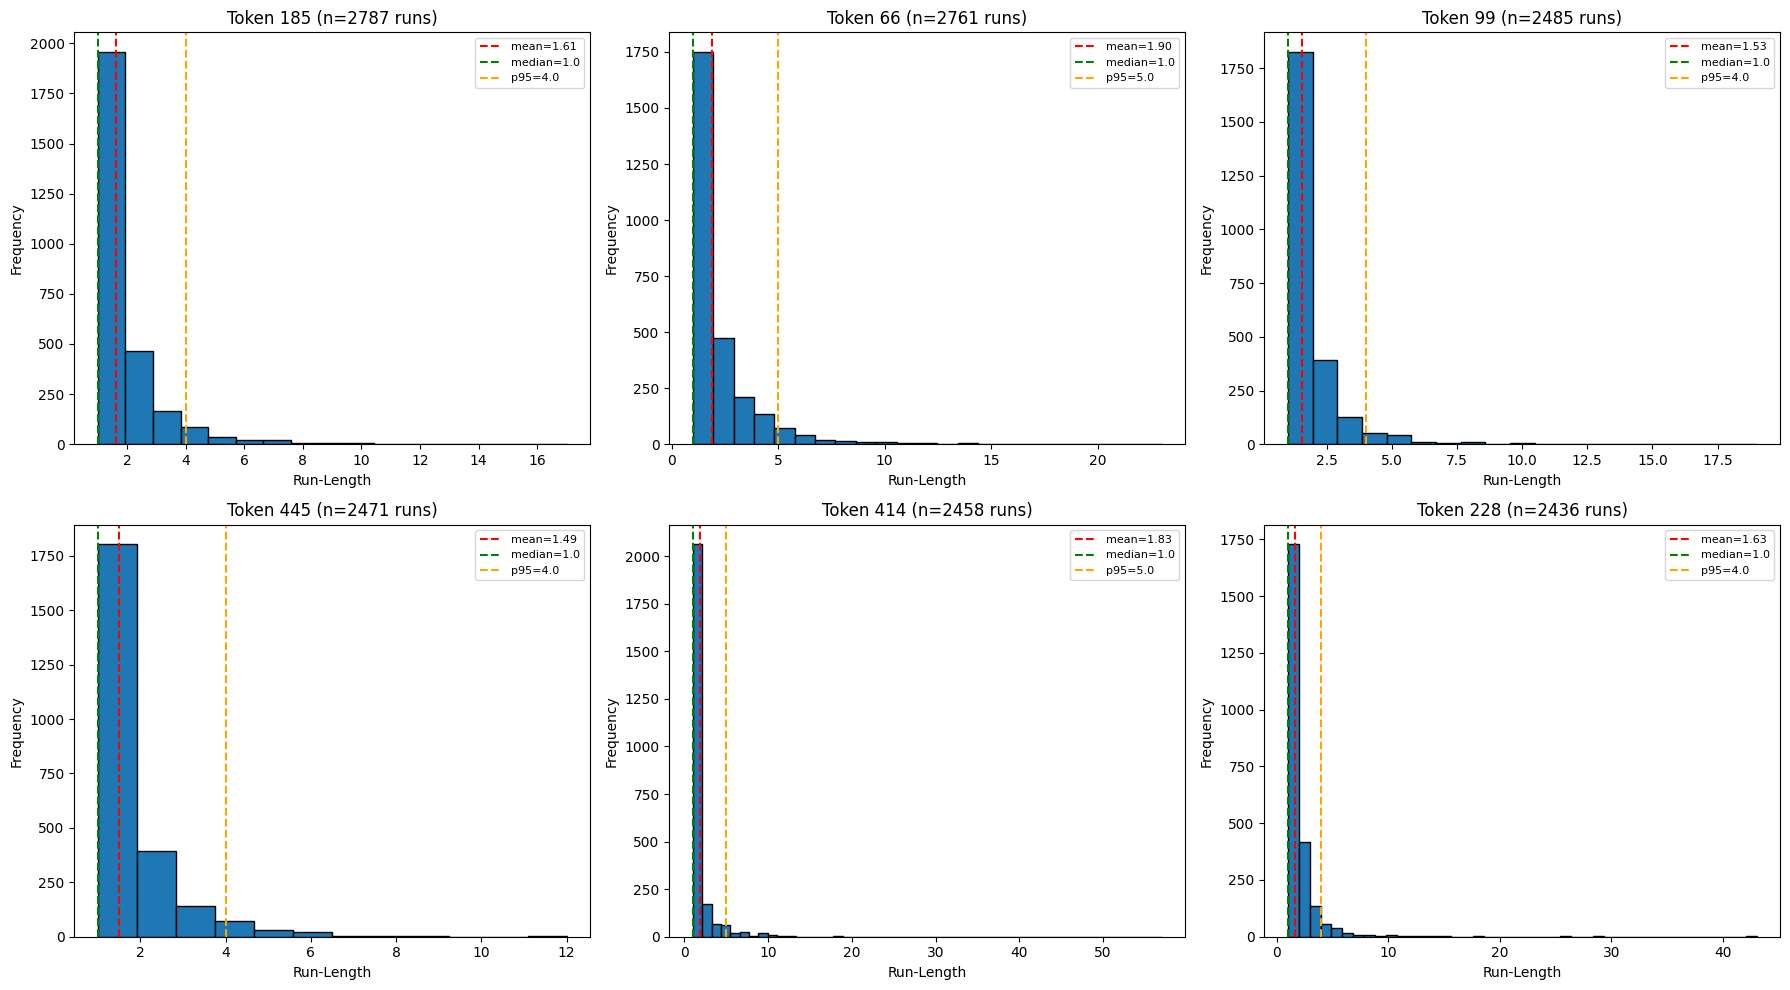

In [73]:
# Show run-length distributions for a few specific tokens

# Get tokens with highest frequency
top_tokens = sorted(token_stats.items(), key=lambda x: x[1]['count'], reverse=True)[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (token_id, stats) in enumerate(top_tokens):
    run_lengths = token_run_lengths[token_id]
    axes[idx].hist(run_lengths, bins=min(50, max(run_lengths)), edgecolor='black')
    axes[idx].set_xlabel('Run-Length')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Token {token_id} (n={stats["count"]} runs)')
    axes[idx].axvline(stats['mean'], color='red', linestyle='--', label=f'mean={stats["mean"]:.2f}')
    axes[idx].axvline(stats['median'], color='green', linestyle='--', label=f'median={stats["median"]:.1f}')
    axes[idx].axvline(stats['p95'], color='orange', linestyle='--', label=f'p95={stats["p95"]:.1f}')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()


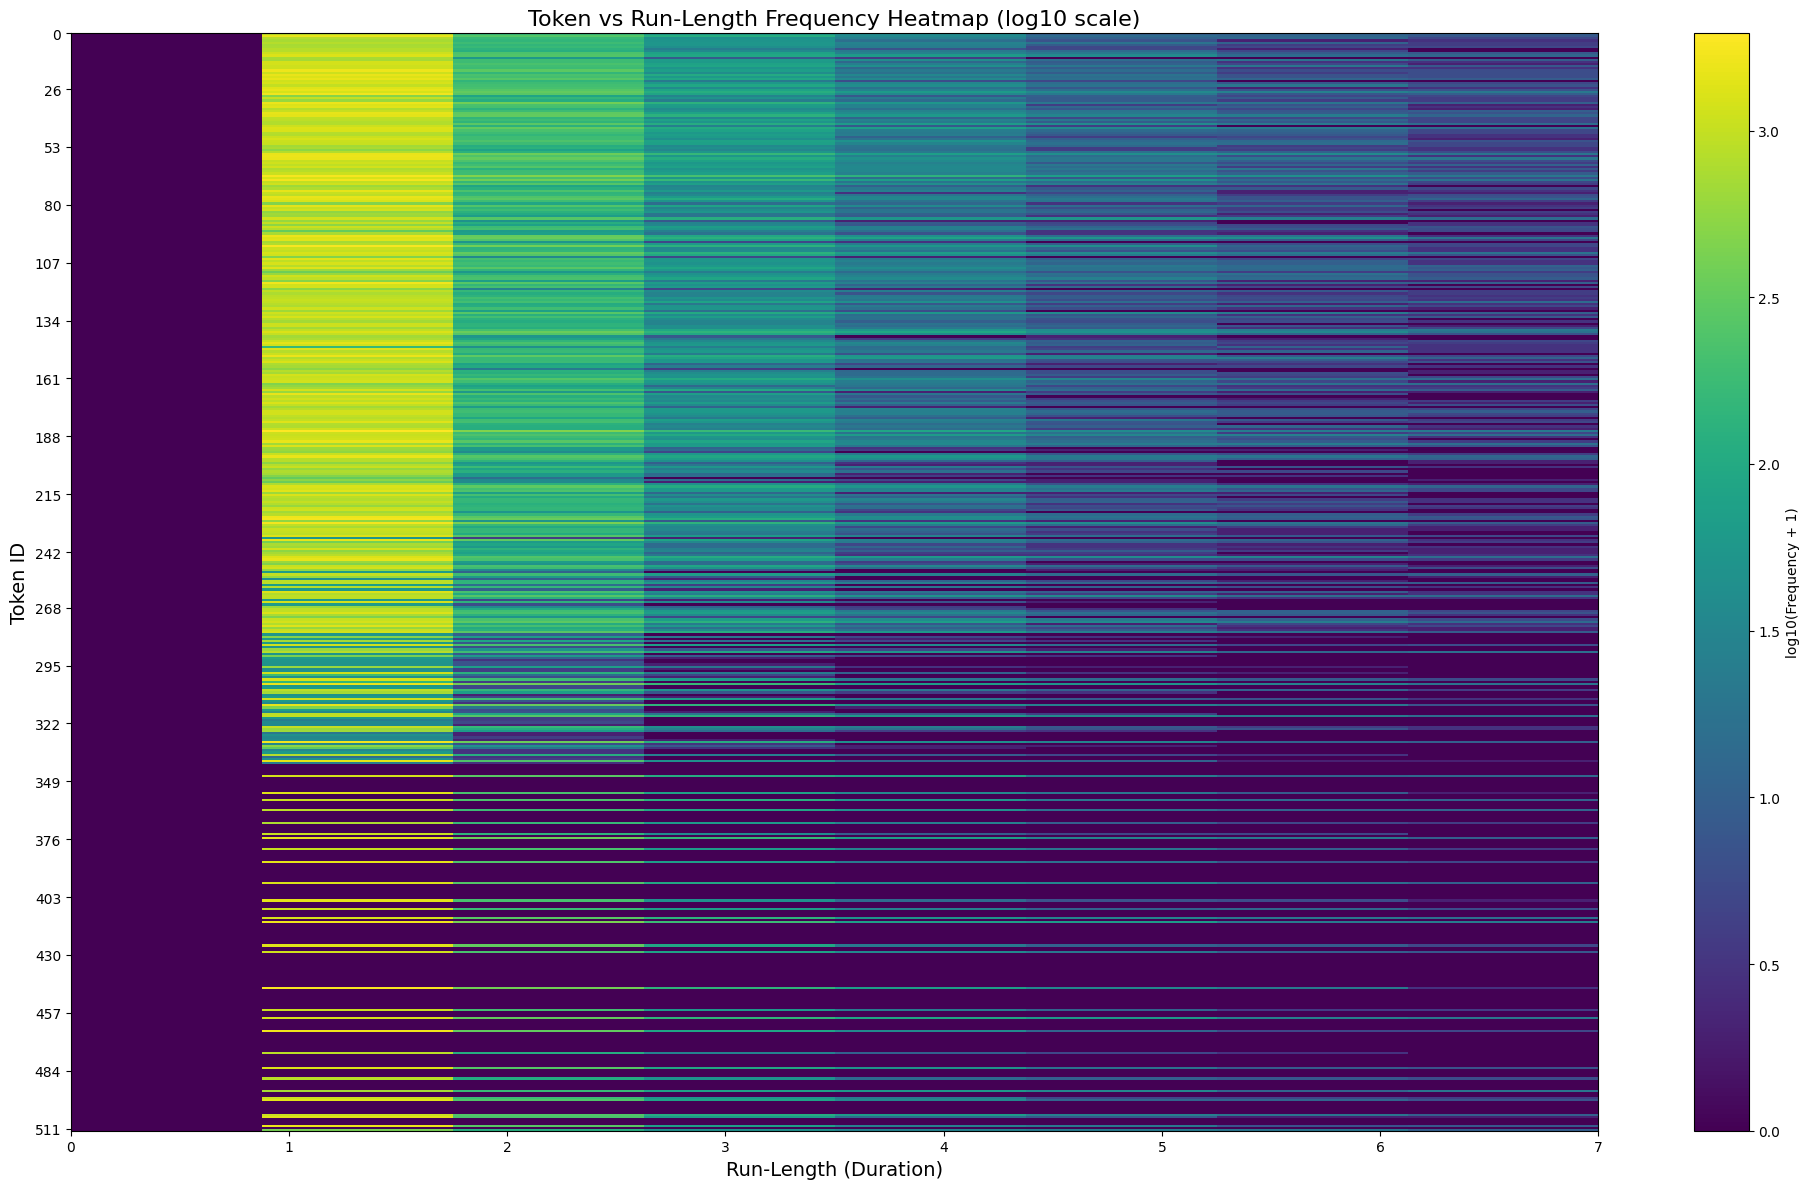


Heatmap statistics:
  Number of tokens shown: 512
  Max run-length shown: 7
  Total data points: 422047


In [74]:
# Create heatmap of token vs run-length frequency

# Determine the maximum run-length to consider for visualization
all_run_lengths = [rl for rls in token_run_lengths.values() for rl in rls]
max_run_length = int(np.percentile(all_run_lengths, 99))  # Use 99th percentile to avoid extreme outliers

# Create 2D histogram: tokens (y-axis) vs run-lengths (x-axis)
heatmap_data = np.zeros((vocab_size, max_run_length + 1))

for token_id, run_lengths in token_run_lengths.items():
    for rl in run_lengths:
        if rl <= max_run_length:
            heatmap_data[token_id, rl] += 1

# Filter to only show tokens that actually appear
tokens_with_data = [i for i in range(vocab_size) if token_id in token_run_lengths]
heatmap_data_filtered = heatmap_data[tokens_with_data, :]

# Create the heatmap
fig, ax = plt.subplots(figsize=(20, 12))

# Use log scale for better visualization (many cells will have 0 or low counts)
im = ax.imshow(np.log10(heatmap_data_filtered + 1), cmap='viridis', aspect='auto', 
               interpolation='nearest', extent=[0, max_run_length, len(tokens_with_data), 0])

ax.set_xlabel('Run-Length (Duration)', fontsize=14)
ax.set_ylabel('Token ID', fontsize=14)
ax.set_title('Token vs Run-Length Frequency Heatmap (log10 scale)', fontsize=16)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, label='log10(Frequency + 1)')

# Add some y-tick labels to show actual token IDs (sample them)
if len(tokens_with_data) > 50:
    tick_positions = np.linspace(0, len(tokens_with_data) - 1, 20, dtype=int)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels([tokens_with_data[i] for i in tick_positions])
else:
    ax.set_yticks(range(len(tokens_with_data)))
    ax.set_yticklabels(tokens_with_data)

plt.tight_layout()
plt.show()

print(f"\nHeatmap statistics:")
print(f"  Number of tokens shown: {len(tokens_with_data)}")
print(f"  Max run-length shown: {max_run_length}")
print(f"  Total data points: {int(heatmap_data_filtered.sum())}")



Correlation between Token ID and Mean Run-Length:
  Pearson correlation: -0.1034 (p-value: 4.6489e-02)
  Spearman correlation: -0.3094 (p-value: 1.1386e-09)


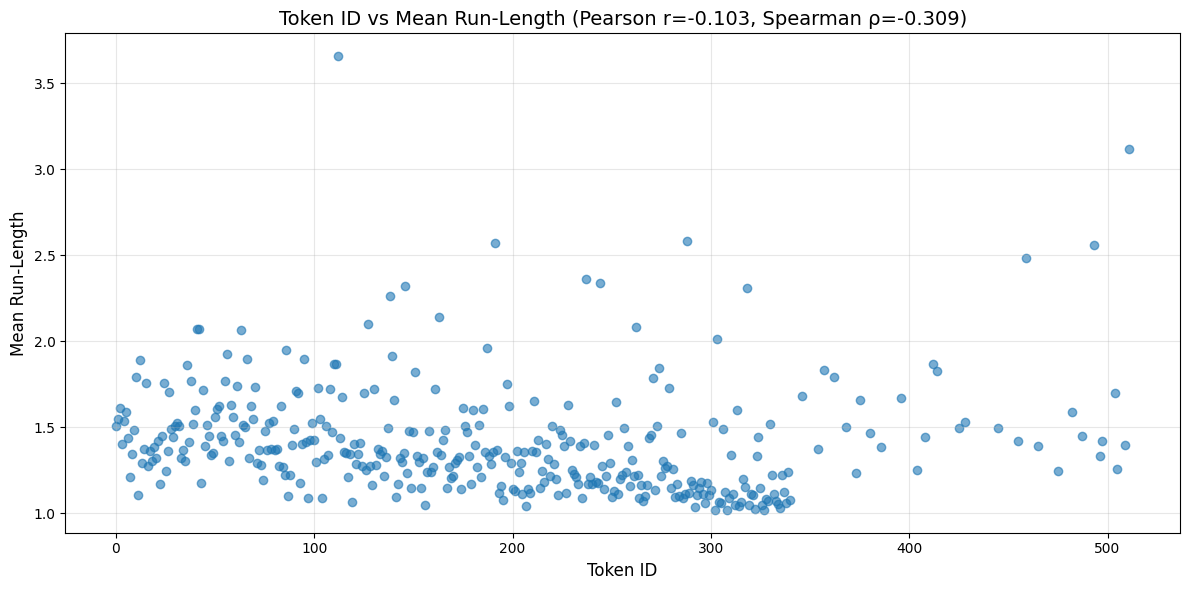

In [75]:
# Compute correlation between token ID and mean run-length
token_ids = []
mean_rls = []

for token_id in range(vocab_size):
    if token_id in token_stats:
        token_ids.append(token_id)
        mean_rls.append(token_stats[token_id]['mean'])

# Compute Pearson and Spearman correlations
from scipy.stats import pearsonr, spearmanr

pearson_corr, pearson_pval = pearsonr(token_ids, mean_rls)
spearman_corr, spearman_pval = spearmanr(token_ids, mean_rls)

print(f"\nCorrelation between Token ID and Mean Run-Length:")
print(f"  Pearson correlation: {pearson_corr:.4f} (p-value: {pearson_pval:.4e})")
print(f"  Spearman correlation: {spearman_corr:.4f} (p-value: {spearman_pval:.4e})")

# Scatter plot to visualize
plt.figure(figsize=(12, 6))
plt.scatter(token_ids, mean_rls, alpha=0.6)
plt.xlabel('Token ID', fontsize=12)
plt.ylabel('Mean Run-Length', fontsize=12)
plt.title(f'Token ID vs Mean Run-Length (Pearson r={pearson_corr:.3f}, Spearman ρ={spearman_corr:.3f})', 
          fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
@torch.no_grad()
def inference(
    model: torch.nn.Module, 
    dataset: AppendageDataset,
    seen_so_far: int = 100,
    allow_repeats: bool = True,
    sample_strategy: str = "multinomial",
    temperature: float = 1.0,
) -> torch.Tensor:
    region_data, appendage_data = dataset[1]
    region_data = torch.tensor(region_data).unsqueeze(0).to(device)
    first_region_token = region_data[:, :seen_so_far]
    region_tokens_so_far = list(first_region_token.tolist()[0])

    for _ in tqdm(range(30)):
        output = model(
            torch.tensor(region_tokens_so_far).unsqueeze(0)
        ).squeeze(0)

        durations = None
        if len(output) == 2:
            region_token_logits, durations = output
        else:
            region_token_logits = output

        region_token_logits = region_token_logits.squeeze(0)

        if not allow_repeats:
            last_token = region_tokens_so_far[-1]
            region_token_logits[-1, last_token] = -float('inf')

        if sample_strategy == "greedy":
            best_region_token = torch.argmax(region_token_logits[-1]).item()
        elif sample_strategy == "multinomial":
            region_probs = torch.softmax(region_token_logits / temperature, dim=1)[-1]
            best_region_token = torch.multinomial(region_probs, num_samples=1).item()

        region_tokens_so_far.append(best_region_token)

    appendage_values = dataset.vqvae.decode(torch.tensor(region_tokens_so_far).unsqueeze(0).to(device)).squeeze(0)

    return region_tokens_so_far, appendage_values  # (T, 12)

@torch.no_grad()
def inference_durations(
    model: torch.nn.Module, 
    dataset: AppendageDataset,
    log: bool = False,
    seen_so_far: int = 100,
    sample_strategy: str = "multinomial",
    temperature: float = 1.0,
    verbose: bool = False,
) -> torch.Tensor:
    data = dataset[0]

    gt_tokens = data["tokens"]
    gt_durations = data["durations"]

    gt_tokens = torch.tensor(gt_tokens).unsqueeze(0).to(device)
    first_token = gt_tokens[:, :seen_so_far]
    tokens_so_far = list(first_token.tolist()[0])

    for _ in tqdm(range(30)):
        output = model(
            torch.tensor(tokens_so_far).unsqueeze(0).to(device)
        )

        token_logits, durations = output
        token_logits = token_logits.squeeze(0).cpu()
        durations = durations.squeeze(0).cpu()

        predicted_duration = durations[-1].item()
        
        if verbose:
            if log:
                print(f"Predicted log-durations: {predicted_duration:.2f}, Ground truth: {torch.log10(torch.tensor(gt_durations[len(tokens_so_far)-1], dtype=torch.float32)).item():.2f}")
            else:
                print(f"Predicted durations: {predicted_duration:.2f}, Ground truth: {gt_durations[len(tokens_so_far)-1]}")

        # Sample the next token
        if sample_strategy == "greedy":
            best_region_token = torch.argmax(token_logits[-1]).item()
        elif sample_strategy == "multinomial":
            region_probs = torch.softmax(token_logits / temperature, dim=1)[-1]
            best_region_token = torch.multinomial(region_probs, num_samples=1).item()

        # Convert predicted duration to number of frames
        if not log:
            duration = max(1, round(predicted_duration))
        else:
            duration = max(1, round(10 ** predicted_duration))
        
        # Append the sampled token for the predicted duration
        for d in range(duration):
            tokens_so_far.append(best_region_token)
        
        if verbose:
            print(f"  Sampled token {best_region_token} for {duration} frames, total length: {len(tokens_so_far)}")

    appendage_values = dataset.vqvae.decode(torch.tensor(tokens_so_far).unsqueeze(0).to(device)).squeeze(0)

    return tokens_so_far, appendage_values  # (T, 12)

In [7]:
def plot_out(
    model: torch.nn.Module,
    dataset: AppendageDataset,
    inference,
    log: bool = False,
):
    out, pred_appendage = inference(model, dataset, log=log, seen_so_far=20, sample_strategy="multinomial", temperature=1.0, verbose=True)
    # region_tokens, appendage_values = dataset[1]
    data = dataset[0]
    region_tokens = data["tokens"]
    appendage_values = data["values"]

    pred_appendage = pred_appendage.cpu().numpy()

    fig, ax = plt.subplots(1, 5, figsize=(15, 5))

    num_plot = 50

    ax[0].plot(out[10:num_plot], label="pred")
    ax[0].plot(region_tokens[10:num_plot], label="region true")
    ax[0].legend()

    ax[1].plot(pred_appendage[:num_plot, 0], label="pred")
    ax[1].plot(appendage_values[:num_plot, 0], label="app 0")
    ax[1].legend()

    ax[2].plot(pred_appendage[:num_plot, 4], label="pred")
    ax[2].plot(appendage_values[:num_plot, 4], label="app 4")
    ax[2].legend()

    ax[3].plot(pred_appendage[:num_plot, 7], label="pred")
    ax[3].plot(appendage_values[:num_plot, 7], label="app 7")
    ax[3].legend()

    ax[4].plot(pred_appendage[:num_plot, 11], label="pred")
    ax[4].plot(appendage_values[:num_plot, 11], label="app 13")
    ax[4].legend()

    plt.show()

    return out

 40%|████      | 12/30 [00:00<00:00, 63.02it/s]

Predicted durations: 1.92, Ground truth: 8
  Sampled token 396 for 2 frames, total length: 22
Predicted durations: 1.84, Ground truth: 6
  Sampled token 6 for 2 frames, total length: 24
Predicted durations: 2.17, Ground truth: 4
  Sampled token 357 for 2 frames, total length: 26
Predicted durations: 1.35, Ground truth: 2
  Sampled token 6 for 1 frames, total length: 27
Predicted durations: 1.20, Ground truth: 1
  Sampled token 396 for 1 frames, total length: 28
Predicted durations: 1.08, Ground truth: 2
  Sampled token 455 for 1 frames, total length: 29
Predicted durations: 2.08, Ground truth: 1
  Sampled token 396 for 2 frames, total length: 31
Predicted durations: 1.33, Ground truth: 1
  Sampled token 357 for 1 frames, total length: 32
Predicted durations: 1.05, Ground truth: 1
  Sampled token 6 for 1 frames, total length: 33
Predicted durations: 1.00, Ground truth: 2
  Sampled token 58 for 1 frames, total length: 34
Predicted durations: 1.01, Ground truth: 1
  Sampled token 202 for 

 63%|██████▎   | 19/30 [00:00<00:00, 42.98it/s]

Predicted durations: 1.04, Ground truth: 3
  Sampled token 357 for 1 frames, total length: 39
Predicted durations: 1.01, Ground truth: 2
  Sampled token 396 for 1 frames, total length: 40
Predicted durations: 1.00, Ground truth: 1
  Sampled token 396 for 1 frames, total length: 41
Predicted durations: 1.00, Ground truth: 5
  Sampled token 260 for 1 frames, total length: 42
Predicted durations: 1.00, Ground truth: 4
  Sampled token 497 for 1 frames, total length: 43
Predicted durations: 1.13, Ground truth: 3
  Sampled token 260 for 1 frames, total length: 44
Predicted durations: 1.01, Ground truth: 2


 80%|████████  | 24/30 [00:00<00:00, 38.50it/s]

  Sampled token 78 for 1 frames, total length: 45
Predicted durations: 1.00, Ground truth: 1
  Sampled token 509 for 1 frames, total length: 46
Predicted durations: 1.01, Ground truth: 6
  Sampled token 386 for 1 frames, total length: 47
Predicted durations: 1.00, Ground truth: 5
  Sampled token 1 for 1 frames, total length: 48
Predicted durations: 1.01, Ground truth: 4
  Sampled token 3 for 1 frames, total length: 49
Predicted durations: 0.99, Ground truth: 3
  Sampled token 2 for 1 frames, total length: 50


100%|██████████| 30/30 [00:00<00:00, 37.59it/s]

Predicted durations: 1.01, Ground truth: 2
  Sampled token 3 for 1 frames, total length: 51
Predicted durations: 1.18, Ground truth: 1
  Sampled token 386 for 1 frames, total length: 52
Predicted durations: 1.00, Ground truth: 1
  Sampled token 86 for 1 frames, total length: 53
Predicted durations: 1.00, Ground truth: 2
  Sampled token 6 for 1 frames, total length: 54
Predicted durations: 1.63, Ground truth: 1
  Sampled token 86 for 2 frames, total length: 56


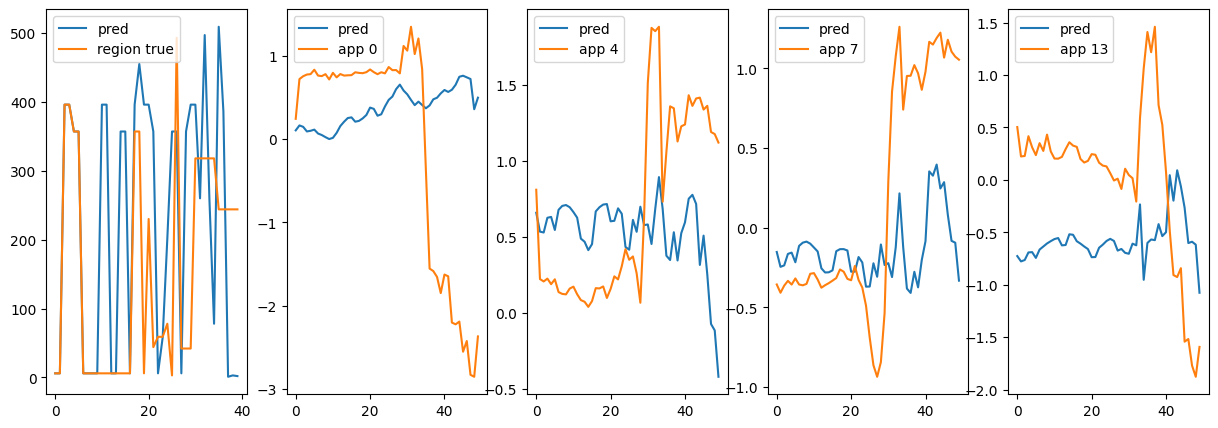

In [8]:
out = plot_out(model, dataset, inference_durations, log=False)

In [9]:
out[19:]

[6,
 396,
 396,
 6,
 6,
 357,
 357,
 6,
 396,
 455,
 396,
 396,
 357,
 6,
 58,
 202,
 357,
 357,
 6,
 357,
 396,
 396,
 260,
 497,
 260,
 78,
 509,
 386,
 1,
 3,
 2,
 3,
 386,
 86,
 6,
 86,
 86]

In [113]:
inference_durations(model, dataset, verbose=True, log=True)

  0%|          | 0/30 [00:00<?, ?it/s]

  3%|▎         | 1/30 [00:01<00:32,  1.13s/it]

Predicted log-durations: 0.00, Ground truth: 0.00


  7%|▋         | 2/30 [00:02<00:30,  1.10s/it]

Predicted log-durations: 0.00, Ground truth: 0.00


...

 97%|█████████▋| 29/30 [00:32<00:01,  1.11s/it]

Predicted log-durations: -0.00, Ground truth: 0.00


100%|██████████| 30/30 [00:33<00:00,  1.12s/it]

Predicted log-durations: -0.00, Ground truth: 0.00


([31,
  396,
  396,
  396,
  396,
  396,
  396,
  396,
  357,
  6,
  396,
  396,
  396,
  357,
  357,
  357,
  6,
  6,
  6,
  396,
  357,
  6,
  6,
  6,
  6,
  6,
  6,
  357,
  357,
  396,
  230,
  44,
  59,
  59,
  312,
  3,
  493,
  42,
  42,
  318,
  318,
  318,
  244,
  318,
  318,
  244,
  244,
  15,
  15,
  15,
  244,
  244,
  318,
  318,
  42,
  42,
  42,
  213,
  44,
  270,
  44,
  44,
  44,
  44,
  230,
  455,
  230,
  88,
  396,
  86,
  86,
  86,
  86,
  86,
  86,
  86,
  86,
  357,
  357,
  357,
  357,
  357,
  357,
  357,
  357,
  357,
  357,
  357,
  357,
  357,
  357,
  357,
  263,
  6,
  6,
  396,
  86,
  166,
  86,
  166,
  86,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166,
  166],
 tensor([[ 0.3895,  1.1757,  0.2527,  ..., -1.6999,  0.9296, -0.7086],
         [ 0.6481,  0.6020,  0.2791,  ..., -1.6496,  0.9775, -0.5845],
  

In [ ]:
## Analysis of `inference_durations` sampling

The current implementation has a subtle issue:

**Training data format:**
- For each position `i`, `durations[i]` = remaining frames until token changes (counting from position i)
- At position where token just changed: duration is large (e.g., 10)
- At positions during a run: duration decreases (9, 8, 7, ..., 1)

**Inference issue:**
After sampling token and appending it `duration` times, the next forward pass includes all those repetitions. When we use `durations[-1]`, we're getting the prediction for the **last position** in an expanded sequence.

**Example:**
1. Start: `[1,1,1,...,1]` (100 tokens)
2. Predict token=5, duration=10 at position 100
3. Append: `[1,1,1,...,1, 5,5,5,5,5,5,5,5,5,5]` (110 tokens total)
4. Next iteration: model sees position 110 (the 10th occurrence of token 5)
5. At position 110, the model's duration prediction would be close to 1 (about to change), not a fresh duration for a new token

**The bug:** We're sampling new tokens too frequently because we're not respecting that mid-run positions shouldn't trigger new samples.